In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tsa_evaluation_results.json
/kaggle/input/gcv-ocr.csv
/kaggle/input/vsa_expt_results.json
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral6.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral12.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral7.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral15.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral2.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral11.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral8.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral14.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral1.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral10.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral4.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral13.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral5.jpg
/kaggle/input/dataset/Dataset/Small/Test/neutral/neutral3.jpg
/kaggle/input/dataset/

In [ ]:
!pip install -q ftfy regex tqdm torch torchvision git+https://github.com/openai/CLIP.git

import os
import sys
os._exit(00)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.2 MB/s eta 0:00

In [3]:
# ======================= #
#     STEP 1: IMPORTS     #
# ======================= #
# Install OpenAI CLIP (if not already)
# !pip install -q git+https://github.com/openai/CLIP.git

# Imports
import os
import pandas as pd
import torch
import clip
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm


  Preparing metadata (setup.py) ... done


In [4]:
class CustomImageDataset(Dataset):
    def __init__(self, csv_file, img_dir, preprocess, label_encoder):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.preprocess = preprocess
        self.label_encoder = label_encoder
        self.data['sentiment'] = self.label_encoder.fit_transform(self.data['sentiment'].str.lower().str.strip())

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = self.preprocess(Image.open(img_path))
        label = row['sentiment']
        return image, label

In [5]:
# os.listdir("/kaggle/input/basket")
import os

temp_data = pd.DataFrame(columns=["filename","label"])
all_files = os.listdir("/kaggle/input/dataset/basket")
all_files.sort()

In [11]:
import os

temp_data = pd.DataFrame(columns=["filename","label"])
all_files = os.listdir("/kaggle/input/dataset/basket")
all_files.sort()

for file in all_files:
    label = file.split("_")[0]
    # print(label)
    # print(file)
    temp_data = pd.concat([temp_data, pd.DataFrame([[file, label]], columns=["filename", "sentiment"])], ignore_index=True)
    # print(temp_data)
    # break

# Optional: Display the DataFrame
print(temp_data.head())

           filename label sentiment
0  negative_001.jpg   NaN  negative
1  negative_002.jpg   NaN  negative
2  negative_003.jpg   NaN  negative
3  negative_004.jpg   NaN  negative
4  negative_005.jpg   NaN  negative


In [12]:
temp_data.to_csv("temp_data.csv", index=False)

In [13]:
# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
# Load CLIP + Preprocess
clip_model, preprocess = clip.load("ViT-B/32", device=device)

In [14]:
temp_data

,filename,label,sentiment
0,negative_001.jpg,NaN,negative
1,negative_002.jpg,NaN,negative
2,negative_003.jpg,NaN,negative
3,negative_004.jpg,NaN,negative
4,negative_005.jpg,NaN,negative
...,...,...,...
2870,positive_995.jpg,NaN,positive
2871,positive_996.jpg,NaN,positive
2872,positive_997.jpg,NaN,positive
2873,positive_998.jpg,NaN,positive


In [35]:
# Freeze CLIP parameters
for param in clip_model.parameters():
    param.requires_grad = False

# Label encoder
le = LabelEncoder()

# Dataset and DataLoader
csv_path = "/kaggle/working/temp_data.csv"
img_dir = "/kaggle/input/dataset/basket/"

dataset = CustomImageDataset(csv_path, img_dir, preprocess, le)

# Split
from torch.utils.data import random_split
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset)) # (len(dataset) - train_size)//2
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size,test_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)


In [36]:
# Get one batch from the dataloader
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([0, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2])


In [37]:
# Image encoder only
image_encoder = clip_model.visual

# Define classifier
class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)  # usually float16
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()  # Convert back to float32 for classifier
        return self.classifier(x)



model = CLIPClassifier(image_encoder, embed_dim=512, num_classes=3).to(device)


In [38]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch


# Updated training loop with:
# - early stopping
# - best model saving
# - loss tracking
# - tqdm.notebook
best_val_loss = float('inf')
patience = 3
counter = 0
train_losses = []
val_losses = []


# Define optimizer and loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)


for epoch in range(10):  # You can increase this
    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_clip_model.pt")
        print("✅ Model saved.")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⛔ Early stopping triggered.")
            break

Epoch 1 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 1, Train Loss: 0.9332, Val Loss: 0.8181
✅ Model saved.


Epoch 2 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 2 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

...

Epoch 9 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 9, Train Loss: 0.3325, Val Loss: 0.3569
✅ Model saved.


Epoch 10 - Training:   0%|          | 0/144 [00:00<?, ?it/s]

Epoch 10 - Validation:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 10, Train Loss: 0.3146, Val Loss: 0.3419
✅ Model saved.


In [41]:
best_val_loss

0.341857990456952

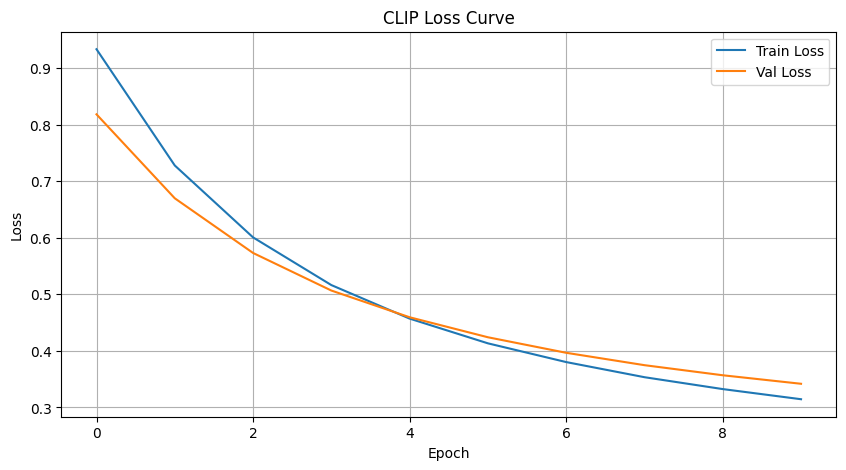

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CLIP Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig("CLIP__loss_curve.png")
plt.show()


In [42]:
# Load best model
model.load_state_dict(torch.load("best_clip_model.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Inference"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Decode labels
class_names = le.classes_

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"🎯 Test Accuracy: {acc * 100:.2f}%")

# Classification Report
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

import json

metrics = {
    "training_loss" : 0.3416,
    "validation_loss" : best_val_loss,
    "test_accuracy": round(acc * 100, 2),
    "classification_report": report,  # This is already a string
    "confusion_matrix": cm.tolist()   # Convert NumPy array to list for JSON
}

with open("test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)


Inference:   0%|          | 0/18 [00:00<?, ?it/s]

🎯 Test Accuracy: 91.32%
              precision    recall  f1-score   support

    negative       0.96      0.88      0.91        98
     neutral       0.85      0.98      0.91        90
    positive       0.94      0.89      0.91       100

    accuracy                           0.91       288
   macro avg       0.92      0.92      0.91       288
weighted avg       0.92      0.91      0.91       288



In [17]:
num_classes

3

In [18]:
len(list(os.listdir(img_dir)))

2875